First, the related libraries were imported and the collected dataset was loaded into the analysis environment.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel("/Users/goksu/Desktop/DSA210/TERM PROJECT/DSA 210 PROJECT DATA.xlsx")

Then, the dataset was examined to ensure that it was read correctly. Missing values, indexes, dataset shape, column types, and the initial structure of the data were checked and printed for an initial overview of the dataset.

In [3]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)
print("\nInfo:")
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())
print("\nFirst 5 rows:")
print(df.head())

Shape: (127, 9)

Columns:
Index(['date', 'departure', 'arrival', 'actual_duration', 'destination',
       'num_lights', 'distance', 'estimated_duration', 'trafic_level'],
      dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 127 entries, 0 to 126
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   date                127 non-null    object
 1   departure           127 non-null    object
 2   arrival             127 non-null    object
 3   actual_duration     127 non-null    object
 4   destination         127 non-null    object
 5   num_lights          127 non-null    int64 
 6   distance            127 non-null    object
 7   estimated_duration  127 non-null    object
 8   trafic_level        127 non-null    object
dtypes: int64(1), object(8)
memory usage: 9.1+ KB
None

Missing values:
date                  0
departure             0
arrival               0
actual_duration       0


Initially, the dataset was cleaned and transformed into a suitable format for analysis. Time-
related variables such as departure and arrival times were converted into datetime format, and
travel durations were standardized in minutes. The final format of the data also provided below.

In [22]:
# Convert duration columns to minutes
def time_to_minutes(x):
    if pd.isnull(x):
        return np.nan

    if isinstance(x, str):
        x = pd.to_datetime(x, errors="coerce").time()

    return x.hour * 60 + x.minute + x.second / 60

df["actual_duration_min"] = df["actual_duration"].apply(time_to_minutes)
df["estimated_duration_min"] = df["estimated_duration"].apply(time_to_minutes)

# Convert date and departure
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["departure"] = pd.to_datetime(df["departure"].astype(str), errors="coerce")

# Rush hour (hour kolonunu tutmadan)
departure_hour = df["departure"].dt.hour

df["rush_hour"] = departure_hour.apply(
    lambda x: "Yes" if (7 <= x <= 9) or (17 <= x <= 19) else "No"
)

# Show date without time
df["date"] = df["date"].dt.date

# Delay
df["delay_min"] = df["actual_duration_min"] - df["estimated_duration_min"]

# Distance cleaning
df["distance"] = df["distance"].astype(str).str.replace("km", "", regex=False)
df["distance"] = df["distance"].str.replace(",", ".", regex=False)
df["distance"] = pd.to_numeric(df["distance"], errors="coerce")

# Traffic level
df["trafic_level"] = df["trafic_level"].astype(str).str.strip()

# Final preview
print()
print("\nFinal Data:")
print(df.head())



Final Data:
         date           departure   arrival actual_duration  \
0  2026-03-31 2026-05-15 07:49:00  08:30:00        00:41:00   
1  2026-03-31 2026-05-15 17:25:00  18:16:00        00:51:00   
2  2026-03-31 2026-05-15 18:31:00  18:36:00        00:05:00   
3  2026-03-31 2026-05-15 20:17:00  20:21:00        00:04:00   
4  2026-04-01 2026-05-15 13:32:00  14:48:00        01:16:00   

           destination  num_lights  distance estimated_duration trafic_level  \
0  Florya - Altunizade          13      29.0           00:44:00       Medium   
1  Altunizade - Florya           8      31.0           00:53:00         High   
2      Florya - Florya           0       0.6           00:02:00          Low   
3      Florya - Florya           0       1.1           00:03:00          Low   
4       Florya - Tuzla          11      64.0           01:14:00       Medium   

   actual_duration_min  estimated_duration_min rush_hour  delay_min  
0                 41.0                    44.0       Yes

Basic statistics of the dataset were checked to better understand the variables and the overall structure of the data.

In [6]:
print("\nSummary statistics:")
print(df[[
    "actual_duration_min",
    "estimated_duration_min",
    "delay_min",
    "distance",
    "num_lights"
]].describe())

print("\nTraffic level counts:")
print(df["trafic_level"].value_counts())

print("\nRush hour counts:")
print(df["rush_hour"].value_counts())


Summary statistics:
       actual_duration_min  estimated_duration_min   delay_min    distance  \
count           127.000000              127.000000  127.000000  127.000000   
mean             44.897638               43.905512    0.992126   29.921260   
std              38.823744               34.637220    9.332905   38.858859   
min               4.000000                2.000000  -22.000000    0.600000   
25%              22.000000               21.000000   -3.000000   10.000000   
50%              41.000000               40.000000    0.000000   26.000000   
75%              57.500000               58.500000    4.000000   38.500000   
max             365.000000              295.000000   70.000000  404.000000   

       num_lights  
count  127.000000  
mean     7.700787  
std      4.685870  
min      0.000000  
25%      4.000000  
50%      7.000000  
75%     11.500000  
max     21.000000  

Traffic level counts:
trafic_level
Medium    56
Low       42
High      29
Name: count, dtype: i

After the initial checks, the analysis continued with EDA visualizations to better explore the patterns and relationships within the dataset.

# Distribution Histograms

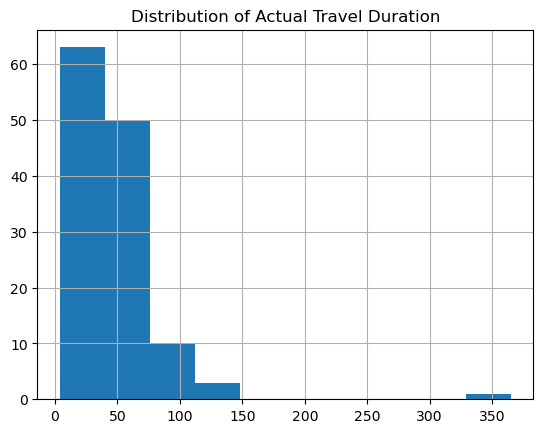

In [8]:
# Duration histogram
print()
plt.figure()
df["actual_duration_min"].hist()
plt.title("Distribution of Actual Travel Duration")
plt.show()

The distribution of actual travel duration is right-skewed, meaning that most trips are relatively short, while a small number of trips take significantly longer. The majority of observations are concentrated between approximately 10 to 60 minutes, indicating that typical daily trips are of moderate duration. However, a few extreme values (outliers) extend the distribution toward higher durations, suggesting occasional long-distance or high-delay trips.

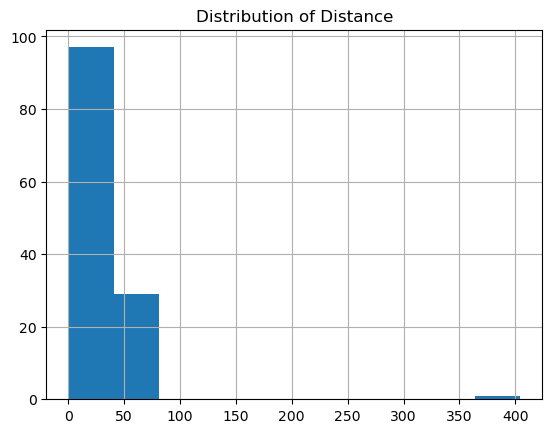

In [9]:
# Distance histogram
print()
plt.figure()
df["distance"].hist()
plt.title("Distribution of Distance")
plt.show()

The distance distribution also exhibits a right-skewed pattern, similar to travel duration. Most trips fall within a shorter distance range (roughly below 50 km), while a very small number of trips reach much higher distances. This indicates that the dataset is dominated by short to medium-range trips, with only a few long- distance journeys.

This pattern is consistent with real-life driving behavior, where most daily trips tend to be relatively short, such as commuting or local travel.

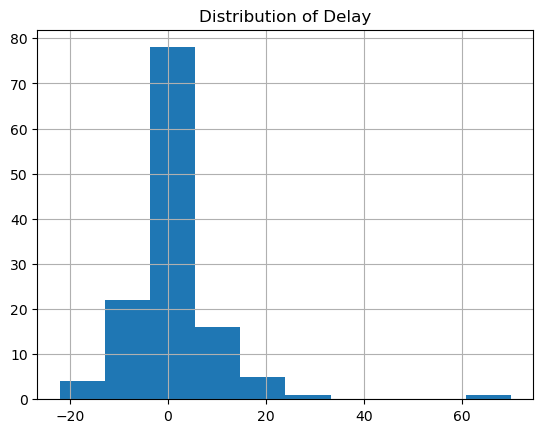

In [10]:
# Delay histogram
print()
plt.figure()
df["delay_min"].hist()
plt.title("Distribution of Delay")
plt.show()

The delay distribution is centered around zero, indicating that estimated travel times are generally
accurate. Most values fall within a narrow range around zero, meaning that the difference between estimated and actual durations is typically small.

However, the distribution includes both negative and positive values:
* Negative values indicate that the estimated time was higher than the actual time (overestimation)
* Positive values indicate underestimation 

The presence of a few extreme values suggests that, in some cases, significant deviations occur, but these are relatively rare.

# Correlations



Correlation (Distance vs Duration): 0.8926833256232678



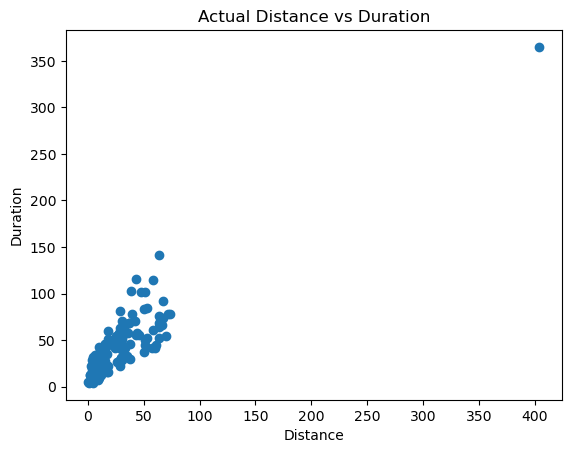

In [11]:
# Distance vs Actual Duration
print()
corr1 = df["distance"].corr(df["actual_duration_min"])
print("\nCorrelation (Distance vs Duration):", corr1)
print()
plt.figure()
plt.scatter(df["distance"], df["actual_duration_min"])
plt.title("Actual Distance vs Duration")
plt.xlabel("Distance")
plt.ylabel("Duration")
plt.show()

A strong positive correlation (≈ 0.89) is observed between distance and actual travel duration. The scatter plot clearly shows a linear upward trend, indicating that as distance increases, travel time increases proportionally.

Most data points are tightly clustered along this trend, suggesting a consistent relationship across
trips. However, a few extreme values (outliers) exist at higher distances, which may represent unusually long trips or atypical traffic conditions.

This result confirms that distance is the dominant factor influencing travel duration.



Correlation (Traffic Lights vs Duration): 0.20421641494095863



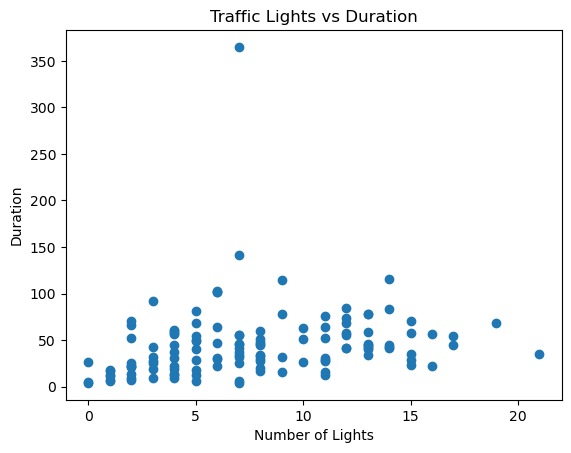

In [12]:
# Traffic lights vs Duration
print()
corr2 = df["num_lights"].corr(df["actual_duration_min"])
print("\nCorrelation (Traffic Lights vs Duration):", corr2)
print()
plt.figure()
plt.scatter(df["num_lights"], df["actual_duration_min"])
plt.title("Traffic Lights vs Duration")
plt.xlabel("Number of Lights")
plt.ylabel("Duration")
plt.show()

The correlation between the number of traffic lights and travel duration is relatively weak (≈
0.20). The scatter plot does not show a strong linear pattern, and the data points are widely dispersed.

Although there is a slight upward tendency, the relationship is not strong enough to significantly explain variations in travel time. This suggests that traffic lights alone are not a major determinant of overall trip duration, and their effect is likely overshadowed by other variables such as distance and traffic level.



Correlation (Estimated vs Actual): 0.9741303922424314



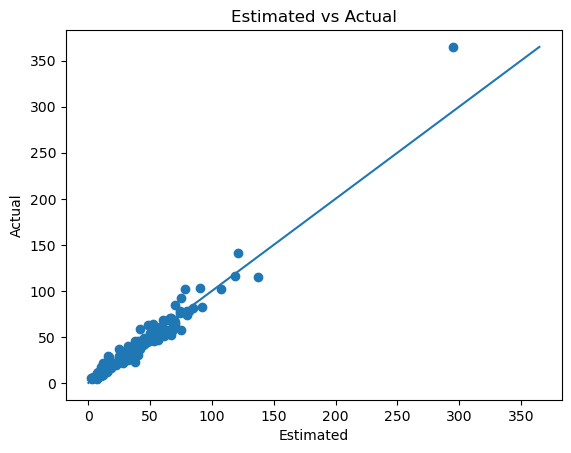

In [13]:
# Estimated vs Actual
print()
corr3 = df["estimated_duration_min"].corr(df["actual_duration_min"])
print("\nCorrelation (Estimated vs Actual):", corr3)
print()
plt.figure()
plt.scatter(df["estimated_duration_min"], df["actual_duration_min"])
plt.title("Estimated vs Actual")
plt.xlabel("Estimated")
plt.ylabel("Actual")

max_val = max(df["estimated_duration_min"].max(), df["actual_duration_min"].max())
plt.plot([0, max_val], [0, max_val])

plt.show()

A very strong positive correlation (≈ 0.97) is observed between estimated and actual travel durations. The data points are closely aligned along a straight line, indicating a near-perfect linear relationship.

This demonstrates that estimated travel times are highly reliable predictors of actual travel duration. The consistency of this relationship suggests that navigation tools such as Google Maps are effective in capturing real-world travel conditions.

# Comparison Boxplots

<Figure size 640x480 with 0 Axes>

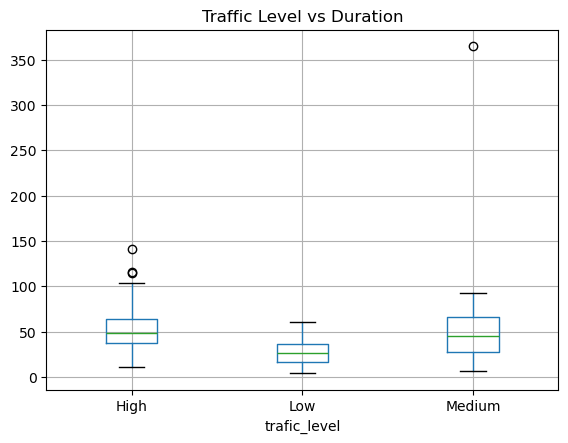

In [14]:
plt.figure()
df.boxplot(column="actual_duration_min", by="trafic_level")
plt.title("Traffic Level vs Duration")
plt.suptitle("")
plt.show()

The boxplot shows a clear relationship between traffic level and travel duration. Trips under low traffic conditions have noticeably lower median durations and a tighter distribution, indicating more consistent and shorter travel times.

In contrast, medium and high traffic levels exhibit higher median durations and greater variability. This suggests that as traffic intensity increases, not only does travel time increase, but it also becomes less predictable.

Additionally, the presence of outliers—especially in the medium traffic category—indicates that under certain conditions, travel duration can increase significantly even when traffic is not at its highest level. Overall, this visual pattern strongly supports the statistical finding that traffic level has a significant impact on travel duration. 

<Figure size 640x480 with 0 Axes>

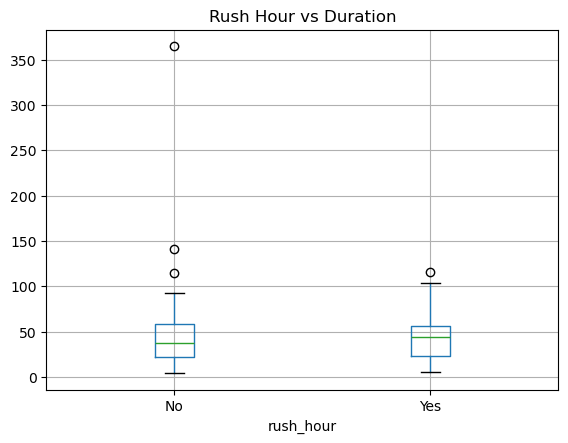

In [15]:
plt.figure()
df.boxplot(column="actual_duration_min", by="rush_hour")
plt.title("Rush Hour vs Duration")
plt.suptitle("")
plt.show()

The boxplot comparing rush hour and non-rush hour trips does not show a clear separation between the two groups. The medians are relatively close, and the spread of the data is similar for both categories.

Although there are some extreme values (outliers), particularly in the non-rush hour group, the overall distributions overlap significantly. This indicates that rush hour alone is not a strong determinant of travel duration.

This observation is consistent with the hypothesis test results, which showed that rush hour
does not have a statistically significant effect. It suggests that traffic level is a more precise
and informative variable than simply categorizing trips based on rush hour.

In [16]:
print("\nAverage duration by traffic level:")
print(df.groupby("trafic_level")["actual_duration_min"].mean())


Average duration by traffic level:
trafic_level
High      58.034483
Low       26.880952
Medium    51.607143
Name: actual_duration_min, dtype: float64


The average values provide additional quantitative evidence on how traffic conditions affect
travel duration and delay.

There is a substantial increase in travel duration as traffic level rises. Trips under medium traffic conditions take nearly twice as long as those under low traffic, while high traffic results in the longest durations.

This confirms that traffic level has a strong and direct impact on travel time, reinforcing both the visual patterns observed in boxplots and the statistical significance found in hypothesis testing.

In [17]:
print("\nAverage delay by traffic level:")
print(df.groupby("trafic_level")["delay_min"].mean())


Average delay by traffic level:
trafic_level
High      1.275862
Low      -0.285714
Medium    1.803571
Name: delay_min, dtype: float64


The average delay values show a more nuanced pattern.
A negative delay under low traffic indicates that estimated travel times are slightly higher than actual durations, meaning trips tend to be faster than expected.

In contrast, under medium and high traffic conditions, delays are positive, suggesting that actual travel times tend to exceed estimated times, although the difference remains relatively small.

# Hypothesis Testing

In [24]:
from scipy import stats


1. Independent T-test: Rush Hour vs Non-Rush Hour
H0: There is no significant difference in actual travel duration between rush hour and non-rush hour trips.
H1: There is a significant difference in actual travel duration between rush hour and non-rush hour trips.
Rush hour mean: 43.785714285714285
Non-rush hour mean: 45.44705882352941
t-statistic: -0.2632160958002544
p-value: 0.792841295508658
Result: Since p-value (0.792841295508658) > 0.05 fail to reject H0. Rush hour does not have a statistically significant effect on travel duration.


<Figure size 700x500 with 0 Axes>

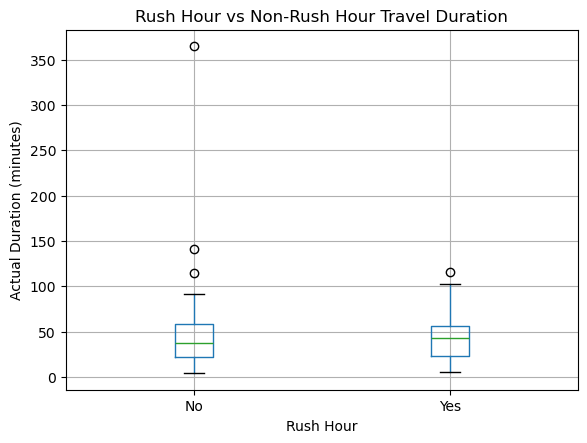

In [25]:
# Rush Hour Effect - Independent t-test
rush = df[df["rush_hour"] == "Yes"]["actual_duration_min"].dropna()
non_rush = df[df["rush_hour"] == "No"]["actual_duration_min"].dropna()

t_stat, p_val = stats.ttest_ind(rush, non_rush, equal_var=False)

print("\n1. Independent T-test: Rush Hour vs Non-Rush Hour")
print("H0: There is no significant difference in actual travel duration between rush hour and non-rush hour trips.")
print("H1: There is a significant difference in actual travel duration between rush hour and non-rush hour trips.")
print("Rush hour mean:", rush.mean())
print("Non-rush hour mean:", non_rush.mean())
print("t-statistic:", t_stat)
print("p-value:", p_val)

if p_val < 0.05:
    print(f"Result: Since p-value ({p_val}) < 0.05 reject H0. Rush hour has a statistically significant effect on travel duration.")
else:
    print(f"Result: Since p-value ({p_val}) > 0.05 fail to reject H0. Rush hour does not have a statistically significant effect on travel duration.")

plt.figure(figsize=(7, 5))
df.boxplot(column="actual_duration_min", by="rush_hour")
plt.title("Rush Hour vs Non-Rush Hour Travel Duration")
plt.suptitle("")
plt.xlabel("Rush Hour")
plt.ylabel("Actual Duration (minutes)")
plt.grid(True)
plt.show()

The p-value was greater than 0.05, leading to a failure to reject the null hypothesis. This
indicates that rush hour does not have a statistically significant effect on travel duration in this
dataset.


2. ANOVA Test: Traffic Level and Actual Duration
H0: Mean actual travel duration is the same across traffic levels.
H1: At least one traffic level has a different mean actual travel duration.
F-statistic: 7.773549942802811
p-value: 0.0006598632376532952
Result: Since p-value (0.0006598632376532952) < 0.05 reject H0. Traffic level has a statistically significant effect on travel duration.


<Figure size 700x500 with 0 Axes>

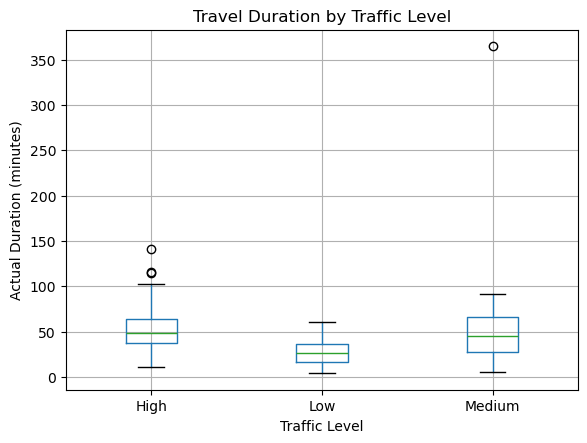

In [26]:
# Traffic Level Effect - ANOVA
traffic_groups = [
    group["actual_duration_min"].dropna()
    for name, group in df.groupby("trafic_level")
]

f_stat, p_val = stats.f_oneway(*traffic_groups)

print("\n2. ANOVA Test: Traffic Level and Actual Duration")
print("H0: Mean actual travel duration is the same across traffic levels.")
print("H1: At least one traffic level has a different mean actual travel duration.")
print("F-statistic:", f_stat)
print("p-value:", p_val)

if p_val < 0.05:
    print(f"Result: Since p-value ({p_val}) < 0.05 reject H0. Traffic level has a statistically significant effect on travel duration.")
else:
    print(f"Result: Since p-value ({p_val}) > 0.05 fail to reject H0. Traffic level does not have a statistically significant effect on travel duration.")

plt.figure(figsize=(7, 5))
df.boxplot(column="actual_duration_min", by="trafic_level")
plt.title("Travel Duration by Traffic Level")
plt.suptitle("")
plt.xlabel("Traffic Level")
plt.ylabel("Actual Duration (minutes)")
plt.grid(True)
plt.show()

The p-value was less than 0.05, leading to rejection of the null hypothesis. This shows that traffic level has a statistically significant impact on travel duration.


3. Paired T-test: Actual Duration vs Estimated Duration
H0: There is no significant difference between actual and estimated travel durations.
H1: There is a significant difference between actual and estimated travel durations.
Actual mean: 44.89763779527559
Estimated mean: 43.90551181102362
t-statistic: 1.1979862916737511
p-value: 0.23317098509478104
Result: Since p-value (0.23317098509478104) > 0.05 fail to reject H0. Google Maps estimates are not significantly different from actual travel durations.


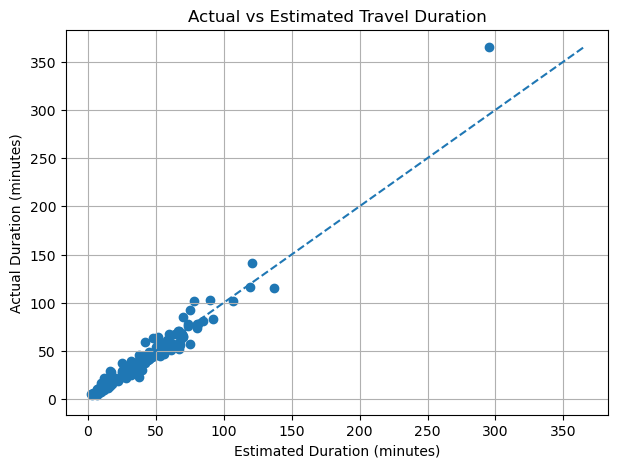

In [27]:
# Google Maps Accuracy - Paired t-test
paired_data = df[["actual_duration_min", "estimated_duration_min"]].dropna()

t_stat, p_val = stats.ttest_rel(
    paired_data["actual_duration_min"],
    paired_data["estimated_duration_min"]
)

print("\n3. Paired T-test: Actual Duration vs Estimated Duration")
print("H0: There is no significant difference between actual and estimated travel durations.")
print("H1: There is a significant difference between actual and estimated travel durations.")
print("Actual mean:", paired_data["actual_duration_min"].mean())
print("Estimated mean:", paired_data["estimated_duration_min"].mean())
print("t-statistic:", t_stat)
print("p-value:", p_val)

if p_val < 0.05:
    print(f"Result: Since p-value ({p_val}) < 0.05 reject H0. Google Maps estimates are significantly different from actual travel durations.")
else:
    print(f"Result: Since p-value ({p_val}) > 0.05 fail to reject H0. Google Maps estimates are not significantly different from actual travel durations.")

plt.figure(figsize=(7, 5))
plt.scatter(df["estimated_duration_min"], df["actual_duration_min"])
min_val = min(df["estimated_duration_min"].min(), df["actual_duration_min"].min())
max_val = max(df["estimated_duration_min"].max(), df["actual_duration_min"].max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.title("Actual vs Estimated Travel Duration")
plt.xlabel("Estimated Duration (minutes)")
plt.ylabel("Actual Duration (minutes)")
plt.grid(True)
plt.show()

The test resulted in a p-value greater than 0.05, indicating no statistically significant difference between estimated and actual travel times. This suggests that Google Maps estimates are generally accurate.


4. Pearson Correlation Test: Distance vs Actual Duration
H0: There is no linear relationship between distance and actual travel duration.
H1: There is a significant linear relationship between distance and actual travel duration.
Correlation coefficient: 0.8926833256232682
p-value: 4.316425990109261e-45
Result: Since p-value (4.316425990109261e-45) < 0.05 reject H0. Distance and actual travel duration have a statistically significant relationship.


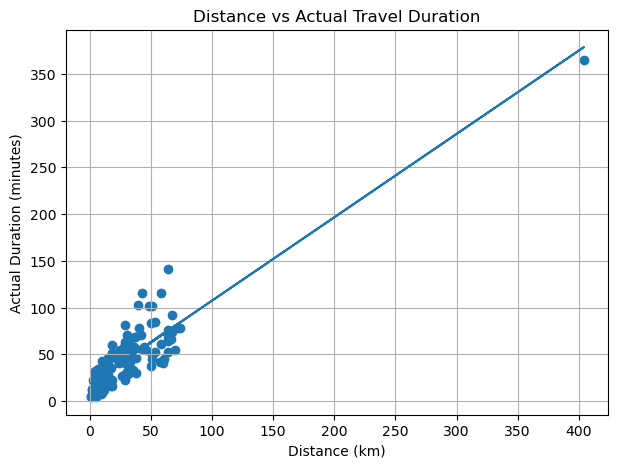



5. Pearson Correlation Test: Number of Traffic Lights vs Actual Duration
H0: There is no linear relationship between number of traffic lights and actual travel duration.
H1: There is a significant linear relationship between number of traffic lights and actual travel duration.
Correlation coefficient: 0.2042164149409588
p-value: 0.02128035468210319
Result: Since p-value (0.02128035468210319) < 0.05 reject H0. Number of traffic lights and actual travel duration have a statistically significant relationship.


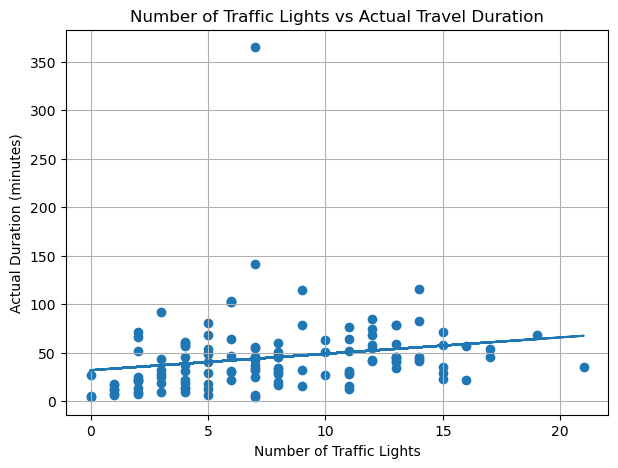

In [32]:
# Distance and Duration Relationship - Pearson correlation test
corr_data = df[["distance", "actual_duration_min"]].dropna()

corr, p_val = stats.pearsonr(
    corr_data["distance"],
    corr_data["actual_duration_min"]
)

print("\n4. Pearson Correlation Test: Distance vs Actual Duration")
print("H0: There is no linear relationship between distance and actual travel duration.")
print("H1: There is a significant linear relationship between distance and actual travel duration.")
print("Correlation coefficient:", corr)
print("p-value:", p_val)

if p_val < 0.05:
    print(f"Result: Since p-value ({p_val}) < 0.05 reject H0. Distance and actual travel duration have a statistically significant relationship.")
else:
    print(f"Result: Since p-value ({p_val}) > 0.05 fail to reject H0. Distance and actual travel duration do not have a statistically significant relationship.")

plt.figure(figsize=(7, 5))
plt.scatter(df["distance"], df["actual_duration_min"])

x = df["distance"]
y = df["actual_duration_min"]
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b)

plt.title("Distance vs Actual Travel Duration")
plt.xlabel("Distance (km)")
plt.ylabel("Actual Duration (minutes)")
plt.grid(True)
plt.show()

print()

# Number of Traffic Lights and Duration - Pearson correlation test
corr_data = df[["num_lights", "actual_duration_min"]].dropna()

corr, p_val = stats.pearsonr(
    corr_data["num_lights"],
    corr_data["actual_duration_min"]
)

print("\n5. Pearson Correlation Test: Number of Traffic Lights vs Actual Duration")
print("H0: There is no linear relationship between number of traffic lights and actual travel duration.")
print("H1: There is a significant linear relationship between number of traffic lights and actual travel duration.")
print("Correlation coefficient:", corr)
print("p-value:", p_val)

if p_val < 0.05:
    print(f"Result: Since p-value ({p_val}) < 0.05 reject H0. Number of traffic lights and actual travel duration have a statistically significant relationship.")
else:
    print(f"Result: Since p-value ({p_val}) > 0.05 fail to reject H0. Number of traffic lights and actual travel duration do not have a statistically significant relationship.")

plt.figure(figsize=(7, 5))
plt.scatter(df["num_lights"], df["actual_duration_min"])

x = df["num_lights"]
y = df["actual_duration_min"]
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b)

plt.title("Number of Traffic Lights vs Actual Travel Duration")
plt.xlabel("Number of Traffic Lights")
plt.ylabel("Actual Duration (minutes)")
plt.grid(True)
plt.show()

Distance showed a statistically significant strong relationship with travel duration (p < 0.05), while the number of traffic lights also showed a statistically significant but weaker relationship.


6. One-sample T-test: Delay
H0: The average delay is equal to 0.
H1: The average delay is significantly different from 0.
Average delay: 0.9921259842519685
t-statistic: 1.1979862916737511
p-value: 0.23317098509478104
Result: Since p-value (0.23317098509478104) > 0.05 fail to reject H0. The average delay is not statistically significantly different from 0.


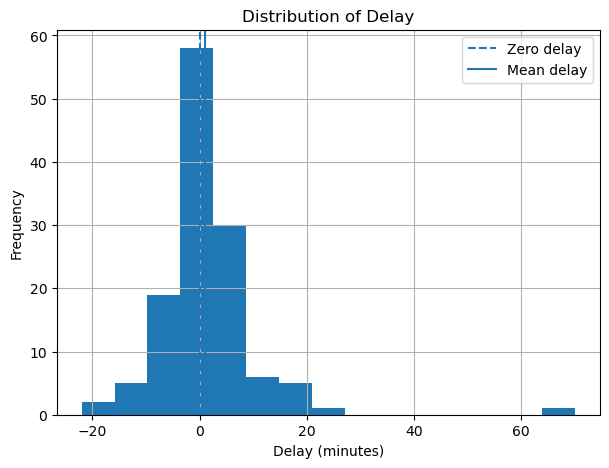

In [30]:
# Delay Test - One-sample t-test
delay_data = df["delay_min"].dropna()

t_stat, p_val = stats.ttest_1samp(delay_data, 0)

print("\n6. One-sample T-test: Delay")
print("H0: The average delay is equal to 0.")
print("H1: The average delay is significantly different from 0.")
print("Average delay:", delay_data.mean())
print("t-statistic:", t_stat)
print("p-value:", p_val)

if p_val < 0.05:
    print(f"Result: Since p-value ({p_val}) < 0.05 reject H0. The average delay is statistically significantly different from 0.")
else:
    print(f"Result: Since p-value ({p_val}) > 0.05 fail to reject H0. The average delay is not statistically significantly different from 0.")

plt.figure(figsize=(7, 5))
plt.hist(df["delay_min"], bins=15)
plt.axvline(0, linestyle="--", label="Zero delay")
plt.axvline(df["delay_min"].mean(), linestyle="-", label="Mean delay")
plt.title("Distribution of Delay")
plt.xlabel("Delay (minutes)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()


The average delay was not significantly different from zero, further supporting the reliability of estimated travel times.

# General Analysis and Interpretation

Overall, the analysis demonstrates that travel duration is primarily influenced by distance and traffic conditions. Both the exploratory data analysis and statistical tests consistently showed that distance has the strongest relationship with actual travel duration. The high Pearson correlation coefficient (approximately 0.89) indicates that longer trips naturally require longer travel times, making distance the most dominant explanatory variable in the dataset. 

Traffic level was also found to be a highly important factor affecting travel duration. The ANOVA test produced a statistically significant result (p < 0.05), confirming that travel times differ across low, medium, and high traffic conditions. In addition, boxplots and average duration comparisons showed that travel duration increases substantially as traffic intensity rises. This suggests that traffic congestion not only increases travel time but also reduces predictability and consistency of trips. 

On the other hand, the number of traffic lights showed only a weak correlation with travel duration. Although the relationship was statistically significant, the low correlation coefficient (~0.20) indicates that traffic lights alone cannot sufficiently explain variations in travel time. Their effect is likely overshadowed by stronger variables such as distance and overall traffic density. 

Another important finding is related to the reliability of Google Maps estimated travel durations. The paired t-test showed no statistically significant difference between estimated and actual durations, while the correlation between them was extremely high (~0.97). These findings suggest that navigation applications are generally successful in predicting real-world travel conditions and can provide reliable duration estimates for daily transportation. 

Interestingly, rush hour itself did not have a statistically significant effect on travel duration. This indicates that simply categorizing a trip as “rush hour” or “non-rush hour” may not fully capture real traffic complexity. Instead, directly measuring traffic level provides a more accurate representation of transportation conditions. 

The delay analysis also supports the reliability of estimated durations. Since the average delay was not significantly different from zero, the estimation system does not systematically overestimate or underestimate travel times. However, slight positive delays observed under medium and high traffic conditions suggest that prediction errors tend to increase when traffic becomes more congested. 

In general, the results indicate that travel duration prediction is highly feasible using variables such as distance, traffic level, and estimated duration. The findings obtained from EDA, hypothesis testing, and later machine learning modeling are consistent with each other, increasing the reliability and validity of the overall project conclusions.